In [1]:
import os
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy import stats, spatial
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
#plt.rcParams['font.family'] = 'Arial'

def readSWC(swc_path, mode='simple'):
    n_skip = 0
    with open(swc_path, "r") as f:
        for line in f.readlines():
            line = line.strip()
            if line.startswith("#"):
                n_skip += 1
            else:
                break
    names = ["##n", "type", "x", "y", "z", "r", "parent"]
    used_cols = [0, 1, 2, 3, 4, 5, 6]
    if mode == 'simple':
        pass
    df = pd.read_csv(swc_path, index_col=0, skiprows=n_skip, sep=" ",
                     usecols=used_cols,
                     names=names
                     )

    return df

from scipy.optimize import curve_fit

import json
with open('../../data/region2primaryRegion.json', 'r') as f:
    region2primaryRegion = json.load(f)

def linear_function(x, a, b):
    return a * x + b

In [2]:
den_contact = pd.read_csv('../../data/ppss_from_boutons.csv', sep=',', index_col=0)

den_contact

,Unnamed: 0,x,y,z,source_cell,target_cell,branch_level,source_region
0,0,3363.26,4075.72,3178.28,15257_2309_x13266_y25533,SEU-ALLEN_local_15257_13261_25519_2290_CCFv3.swc,4,AId
1,1,3413.12,4080.19,3174.42,15257_2309_x13266_y25533,SEU-ALLEN_local_15257_13261_25519_2290_CCFv3.swc,5,AId
2,2,3757.00,3997.74,3287.56,15257_2309_x13266_y25533,SEU-ALLEN_local_17109_7979_9810_2419_CCFv3.swc,9,AId
3,3,3731.85,3929.23,3322.11,15257_2309_x13266_y25533,SEU-ALLEN_local_192349_9355_8926_3356_CCFv3.swc,5,AId
4,4,9236.35,6077.72,4943.05,15257_2627_x17126_y20600,SEU-ALLEN_local_15257_5350_21563_6436_CCFv3.swc,4,TRN
...,...,...,...,...,...,...,...,...
126887,127778,2999.54,3380.95,8394.73,pre_18868_00465,SEU-ALLEN_local_194080_7572_20815_2618_CCFv3.swc,4,MOp
126888,127779,2893.56,3372.85,8401.52,pre_18868_00465,SEU-ALLEN_local_194080_7572_20815_2618_CCFv3.swc,5,MOp
126889,127780,3061.80,3381.16,8372.44,pre_18868_00465,SEU-ALLEN_local_201584_8154_20375_4378_CCFv3.swc,6,MOp
126890,127781,3047.88,3407.62,8455.91,pre_18868_00465,SEU-ALLEN_local_201584_8154_20375_4378_CCFv3.swc,7,MOp


In [3]:
den_contact.drop_duplicates(subset=['x', 'y', 'z'])

,Unnamed: 0,x,y,z,source_cell,target_cell,branch_level,source_region
0,0,3363.26,4075.72,3178.28,15257_2309_x13266_y25533,SEU-ALLEN_local_15257_13261_25519_2290_CCFv3.swc,4,AId
1,1,3413.12,4080.19,3174.42,15257_2309_x13266_y25533,SEU-ALLEN_local_15257_13261_25519_2290_CCFv3.swc,5,AId
2,2,3757.00,3997.74,3287.56,15257_2309_x13266_y25533,SEU-ALLEN_local_17109_7979_9810_2419_CCFv3.swc,9,AId
3,3,3731.85,3929.23,3322.11,15257_2309_x13266_y25533,SEU-ALLEN_local_192349_9355_8926_3356_CCFv3.swc,5,AId
4,4,9236.35,6077.72,4943.05,15257_2627_x17126_y20600,SEU-ALLEN_local_15257_5350_21563_6436_CCFv3.swc,4,TRN
...,...,...,...,...,...,...,...,...
126887,127778,2999.54,3380.95,8394.73,pre_18868_00465,SEU-ALLEN_local_194080_7572_20815_2618_CCFv3.swc,4,MOp
126888,127779,2893.56,3372.85,8401.52,pre_18868_00465,SEU-ALLEN_local_194080_7572_20815_2618_CCFv3.swc,5,MOp
126889,127780,3061.80,3381.16,8372.44,pre_18868_00465,SEU-ALLEN_local_201584_8154_20375_4378_CCFv3.swc,6,MOp
126890,127781,3047.88,3407.62,8455.91,pre_18868_00465,SEU-ALLEN_local_201584_8154_20375_4378_CCFv3.swc,7,MOp


In [4]:
order_list = ['MOp', 'MOs', 'SSp-n', 'SSp-bfd', 'SSs', 'AUDp', 
              'VISp', 'CA1', 'DG', 'POST', 'CP', 'OT', 'MEA', 
              'GPe', 'BST', 'VPL', 'VPM', 'LGd', 'SNr', 'MRN',
              'PAG']

n_cells_per_region = (
    den_contact.drop_duplicates(subset=['target_cell', 'source_region'])
      .groupby('source_region')['target_cell']
      .count()
)
n_cells_per_region[order_list]

source_region
MOp        1300
MOs         918
SSp-n       627
SSp-bfd    1258
SSs        1855
AUDp        381
VISp       1041
CA1          47
DG           40
POST         61
CP         7126
OT          235
MEA          15
GPe          60
BST          23
VPL         138
VPM         303
LGd          49
SNr          23
MRN          51
PAG          10
Name: target_cell, dtype: int64

In [5]:
region_list = n_cells_per_region[n_cells_per_region.values>=10].index
region_list.values

array(['ACAd', 'ACAv', 'ACB', 'AId', 'AIp', 'AIv', 'AOB', 'AON', 'APr',
       'AUDd', 'AUDp', 'AUDpo', 'AUDv', 'BLA', 'BMA', 'BST', 'CA1', 'CA3',
       'CEA', 'CLA', 'COAp', 'CP', 'DG', 'ECT', 'ENTl', 'ENTm', 'EPd',
       'EPv', 'FRP', 'FS', 'GPe', 'GU', 'IA', 'IC', 'LA', 'LGd', 'LP',
       'LSr', 'MEA', 'MOB', 'MOp', 'MOs', 'MRN', 'ORBl', 'ORBm', 'ORBvl',
       'OT', 'PA', 'PAG', 'PAR', 'PARN', 'PERI', 'PG', 'PIR', 'PL', 'PO',
       'POST', 'PRE', 'PT', 'ProS', 'RE', 'RSPagl', 'RSPd', 'RSPv', 'RT',
       'SCm', 'SCs', 'SI', 'SNr', 'SPVC', 'SPVO', 'SSp-bfd', 'SSp-ll',
       'SSp-m', 'SSp-n', 'SSp-tr', 'SSp-ul', 'SSp-un', 'SSs', 'SUB',
       'TEa', 'TR', 'TRN', 'TT', 'VAL', 'VISC', 'VISa', 'VISal', 'VISam',
       'VISl', 'VISli', 'VISp', 'VISpl', 'VISpm', 'VISpor', 'VISrl', 'VM',
       'VPL', 'VPM', 'ZI', 'fiber tracts', 'unknow'], dtype=object)

In [6]:
len(region_list)

102

In [7]:
den_contact = den_contact[den_contact['source_region'].isin(region_list)].copy()
den_contact

,Unnamed: 0,x,y,z,source_cell,target_cell,branch_level,source_region
0,0,3363.26,4075.72,3178.28,15257_2309_x13266_y25533,SEU-ALLEN_local_15257_13261_25519_2290_CCFv3.swc,4,AId
1,1,3413.12,4080.19,3174.42,15257_2309_x13266_y25533,SEU-ALLEN_local_15257_13261_25519_2290_CCFv3.swc,5,AId
2,2,3757.00,3997.74,3287.56,15257_2309_x13266_y25533,SEU-ALLEN_local_17109_7979_9810_2419_CCFv3.swc,9,AId
3,3,3731.85,3929.23,3322.11,15257_2309_x13266_y25533,SEU-ALLEN_local_192349_9355_8926_3356_CCFv3.swc,5,AId
4,4,9236.35,6077.72,4943.05,15257_2627_x17126_y20600,SEU-ALLEN_local_15257_5350_21563_6436_CCFv3.swc,4,TRN
...,...,...,...,...,...,...,...,...
126887,127778,2999.54,3380.95,8394.73,pre_18868_00465,SEU-ALLEN_local_194080_7572_20815_2618_CCFv3.swc,4,MOp
126888,127779,2893.56,3372.85,8401.52,pre_18868_00465,SEU-ALLEN_local_194080_7572_20815_2618_CCFv3.swc,5,MOp
126889,127780,3061.80,3381.16,8372.44,pre_18868_00465,SEU-ALLEN_local_201584_8154_20375_4378_CCFv3.swc,6,MOp
126890,127781,3047.88,3407.62,8455.91,pre_18868_00465,SEU-ALLEN_local_201584_8154_20375_4378_CCFv3.swc,7,MOp


In [8]:
sele_region = region2primaryRegion.keys()
order_list = []

for i in sele_region:
    order_list.append(i)

print(len(order_list))

1086


In [9]:
den_contact_tmp = den_contact[den_contact['source_region'].isin(order_list)].copy()

den_contact_tmp.loc[:, 'count'] = 1

wide_df2_ = den_contact_tmp.pivot_table(index='source_region', columns=['branch_level'], 
                                        values=['count'], aggfunc='sum', fill_value=0)

wide_df2_.columns.name = ''
wide_df2_.columns = [i[1] for i in wide_df2_.columns]
wide_df2_.index.name = ''

wide_df2_.to_csv('../../output/ppss_from_pb_summary.csv')

In [10]:
bouton_df = pd.read_csv('../../output/ppss_from_pb_summary.csv', 
                        sep=',', index_col=0)

pac_df = pd.read_csv('../../output/ppss_from_pac_summary.csv', 
                        sep=',', index_col=0)

In [11]:
bouton_df

,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,21,23
ACAd,8,31,42,92,80,52,33,27,12,6,...,0,1,0,0,0,0,0,0,0,0
ACAv,8,12,25,35,51,53,32,32,26,11,...,1,1,0,0,0,0,0,0,0,0
ACB,6,33,62,123,95,102,58,31,24,11,...,6,1,0,0,0,0,0,0,0,0
AId,33,125,221,315,304,271,186,114,60,28,...,3,1,0,0,0,0,0,0,0,0
AIp,16,47,80,91,76,75,46,24,13,7,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VISrl,11,46,82,138,139,164,112,90,64,34,...,3,0,0,0,0,0,0,0,0,0
VM,0,10,13,14,28,27,28,27,15,9,...,0,1,0,0,0,0,0,0,0,0
VPL,9,25,36,55,67,76,55,44,46,19,...,1,1,0,0,0,0,0,0,0,0
VPM,3,42,64,137,162,165,183,122,108,57,...,10,2,5,0,0,0,0,0,0,0


In [12]:
order_list = ['MOp', 'MOs', 'SSp-n', 'SSp-bfd', 'SSs', 'AUDp', 
              'VISp', 'CA1', 'DG', 'POST', 'CP', 'OT', 'MEA', 
              'GPe', 'BST', 'VPL', 'VPM', 'LGd', 'SNr', 'MRN',
              'PAG']

bouton_df2 = bouton_df.loc[order_list,].copy()
for i in bouton_df2.index:
    bouton_df2.loc[i, :] = bouton_df2.loc[i, :] / n_cells_per_region[order_list].loc[i]
    
bouton_df2 = (bouton_df2.T / bouton_df2.sum(axis=1)).T
bouton_df2 = bouton_df2.loc[:,  [str(i) for i in (range(1,11))]]

bouton_df2

C:\Users\yishui\AppData\Local\Temp\ipykernel_9732\2486307733.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  bouton_df2.loc[i, :] = bouton_df2.loc[i, :] / n_cells_per_region[order_list].loc[i]
C:\Users\yishui\AppData\Local\Temp\ipykernel_9732\2486307733.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2569230769230769' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  bouton_df2.loc[i, :] = bouton_df2.loc[i, :] / n_cells_per_region[order_list].loc[i]
C:\Users\yishui\AppData\Local\Temp\ipykernel_9732\2486307733.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5361538461538462' has dtype incompatib

,1,2,3,4,5,6,7,8,9,10
MOp,0.009875,0.042284,0.088239,0.142043,0.150272,0.155589,0.131029,0.100392,0.076592,0.046715
MOs,0.011254,0.039045,0.084520,0.147910,0.179375,0.172255,0.133900,0.100597,0.049150,0.037207
SSp-n,0.013906,0.052704,0.108498,0.155708,0.166695,0.155193,0.119313,0.096137,0.065751,0.029185
SSp-bfd,0.015974,0.061590,0.114661,0.154952,0.169418,0.156195,0.118743,0.085020,0.059815,0.030795
SSs,0.012180,0.051974,0.102478,0.152247,0.173667,0.163167,0.133347,0.084943,0.051449,0.034124
AUDp,0.020833,0.061458,0.122396,0.163021,0.178646,0.165104,0.109896,0.081250,0.046354,0.031250
VISp,0.024741,0.053951,0.122586,0.158180,0.185315,0.164565,0.120990,0.080128,0.042618,0.026337
CA1,0.000000,0.083333,0.141667,0.233333,0.091667,0.041667,0.050000,0.141667,0.083333,0.066667
DG,0.072464,0.391304,0.188406,0.115942,0.086957,0.072464,0.028986,0.043478,0.000000,0.000000
POST,0.044776,0.089552,0.238806,0.248756,0.179104,0.119403,0.039801,0.034826,0.000000,0.000000


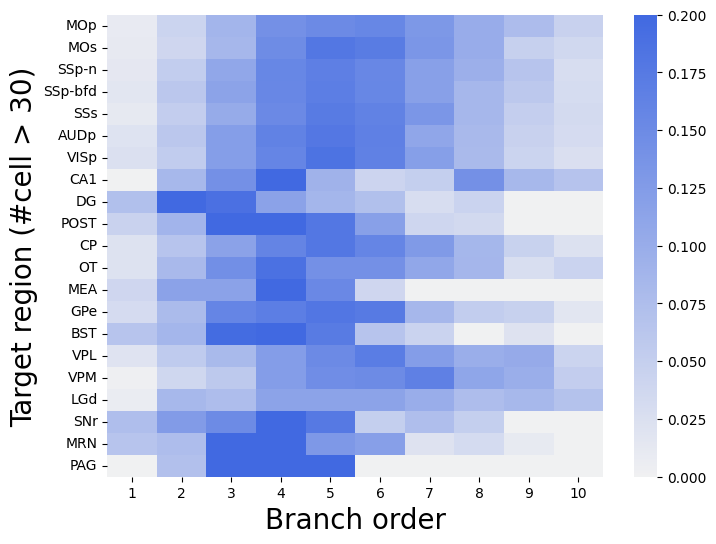

In [13]:
f,ax = plt.subplots(1,1,figsize=(8,6))
sns.heatmap((bouton_df2.loc[order_list, :]), 
            vmin=0, vmax=0.2,
            cmap=sns.color_palette("light:royalblue", as_cmap=True),
           )

cb = ax.collections[0].colorbar
cb.ax.tick_params(labelsize=10)

ax.set_xlabel('Branch order', fontsize=20)
ax.set_ylabel('Target region (#cell > 30)', fontsize=20)

ax.set_xticks(np.arange(0,len(bouton_df2.columns))+0.5, 
              list(range(1,len(bouton_df2.columns)+1)), 
              fontsize=10)

ax.set_yticks(np.arange(0,len(order_list))+0.5, 
              order_list, fontsize=10, rotation=0)
plt.savefig('./bouton_ppss.svg', bbox_inches='tight')
plt.show()

In [14]:
bouton_df

,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,21,23
ACAd,8,31,42,92,80,52,33,27,12,6,...,0,1,0,0,0,0,0,0,0,0
ACAv,8,12,25,35,51,53,32,32,26,11,...,1,1,0,0,0,0,0,0,0,0
ACB,6,33,62,123,95,102,58,31,24,11,...,6,1,0,0,0,0,0,0,0,0
AId,33,125,221,315,304,271,186,114,60,28,...,3,1,0,0,0,0,0,0,0,0
AIp,16,47,80,91,76,75,46,24,13,7,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VISrl,11,46,82,138,139,164,112,90,64,34,...,3,0,0,0,0,0,0,0,0,0
VM,0,10,13,14,28,27,28,27,15,9,...,0,1,0,0,0,0,0,0,0,0
VPL,9,25,36,55,67,76,55,44,46,19,...,1,1,0,0,0,0,0,0,0,0
VPM,3,42,64,137,162,165,183,122,108,57,...,10,2,5,0,0,0,0,0,0,0


In [15]:
bouton_df = (bouton_df.T / bouton_df.sum(axis=1)).T
pac_df = (pac_df.T / pac_df.sum(axis=1)).T

# bouton_df = bouton_df.iloc[:, :10]
# pac_df = pac_df.iloc[:, :10]

In [16]:
shared_region_list = list(set(pac_df.index).intersection(bouton_df.index))
print(len(shared_region_list))

99


In [17]:
pac_df = pac_df.loc[shared_region_list].copy()
bouton_df = bouton_df.loc[shared_region_list].copy()
pac_df

,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
GPe,0.027529,0.085249,0.164914,0.208999,0.179327,0.145501,0.077587,0.050773,0.028957,0.020257,...,0.000584,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
RE,0.017952,0.049324,0.117320,0.197570,0.195476,0.198497,0.114368,0.060925,0.034564,0.008512,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
AOB,0.068051,0.170704,0.274510,0.134948,0.113033,0.121107,0.021915,0.036909,0.050750,0.008074,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
SSp-tr,0.015729,0.072243,0.128195,0.181788,0.172294,0.152182,0.107522,0.086737,0.044492,0.016853,...,0.001685,0.001348,0.000449,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ORBm,0.021013,0.064866,0.116586,0.163311,0.174572,0.176437,0.121639,0.073200,0.040870,0.022057,...,0.000653,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PARN,0.051747,0.262716,0.245024,0.187528,0.156568,0.061920,0.026095,0.002211,0.004865,0.001327,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
MOB,0.074465,0.189081,0.239427,0.197762,0.126805,0.090792,0.041111,0.018099,0.008569,0.007240,...,0.000074,0.000074,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
DG,0.041053,0.141386,0.173247,0.205467,0.184422,0.122491,0.071233,0.035232,0.014521,0.006190,...,0.000226,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
SUB,0.046171,0.104688,0.175359,0.208581,0.176131,0.127119,0.075077,0.044975,0.021570,0.013385,...,0.000011,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
branch_df = bouton_df.stack()
branch_df = branch_df.reset_index()
branch_df.columns= ['region', 'branch_level', 'bouton_probability']
branch_df

,region,branch_level,bouton_probability
0,GPe,1,0.031746
1,GPe,2,0.079365
2,GPe,3,0.158730
3,GPe,4,0.169312
4,GPe,5,0.179894
...,...,...,...
2173,VISl,18,0.000000
2174,VISl,19,0.000000
2175,VISl,20,0.000000
2176,VISl,21,0.000000


In [19]:
branch_df.loc[0, 'region']

'GPe'

In [20]:
branch_df['pac_probability'] = -1
for i in tqdm(branch_df.index):
    tmp_region = branch_df.loc[i, 'region']
    tmp_level = branch_df.loc[i, 'branch_level']
    branch_df.loc[i, 'pac_probability'] = pac_df.loc[tmp_region, tmp_level]

branch_df    

  0%|                                                                                         | 0/2178 [00:00<?, ?it/s]C:\Users\yishui\AppData\Local\Temp\ipykernel_9732\2501329436.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.027528892351642645' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_df.loc[i, 'pac_probability'] = pac_df.loc[tmp_region, tmp_level]
100%|████████████████████████████████████████████████████████████████████████████| 2178/2178 [00:00<00:00, 5665.32it/s]


,region,branch_level,bouton_probability,pac_probability
0,GPe,1,0.031746,0.027529
1,GPe,2,0.079365,0.085249
2,GPe,3,0.158730,0.164914
3,GPe,4,0.169312,0.208999
4,GPe,5,0.179894,0.179327
...,...,...,...,...
2173,VISl,18,0.000000,0.000000
2174,VISl,19,0.000000,0.000000
2175,VISl,20,0.000000,0.000000
2176,VISl,21,0.000000,0.000000


In [21]:
print(stats.pearsonr(
    branch_df['bouton_probability'],
    branch_df['pac_probability']
))

PearsonRResult(statistic=np.float64(0.9118523161534029), pvalue=np.float64(0.0))


In [22]:
x = branch_df['bouton_probability']
y = branch_df['pac_probability']

params, covariance = curve_fit(linear_function, x, y)
a, b = params
x_fit = np.linspace(min(x)-1, max(x)+5, 100)
y_fit = linear_function(x_fit, a, b)

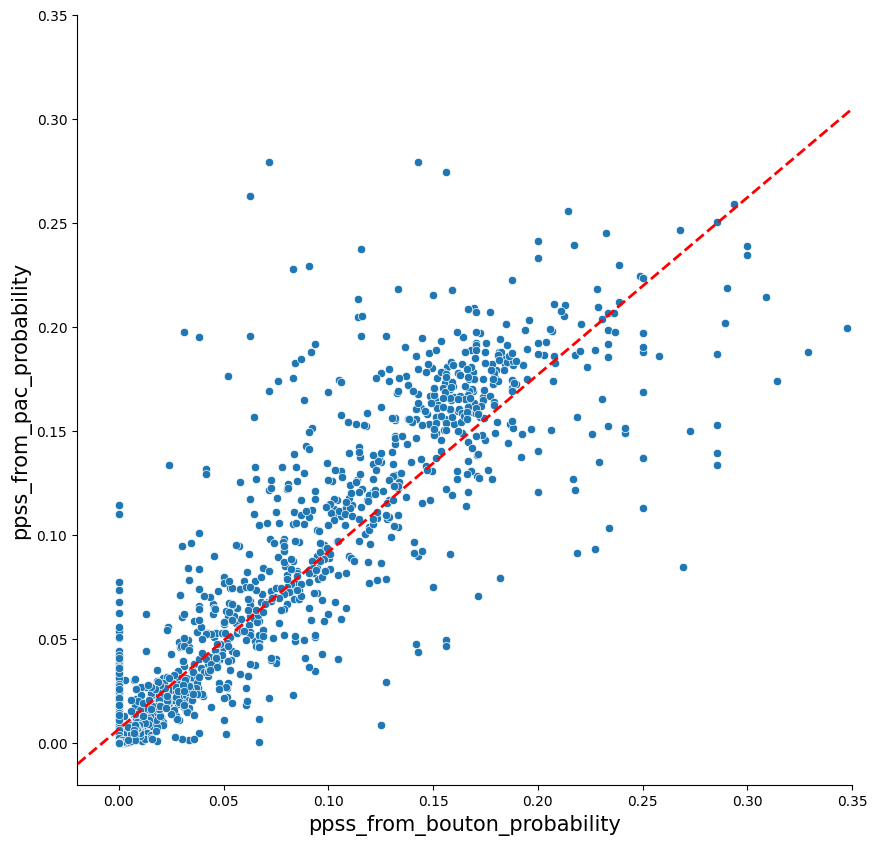

In [23]:
f,ax = plt.subplots(1,1,figsize=(10,10))
sns.scatterplot(data=branch_df, 
                x='bouton_probability', 
                y='pac_probability',
                #hue='branch_level'
               )

plt.plot(x_fit, y_fit, color='red', 
         linewidth=2, linestyle='--',
         label='Fitted Curve')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

ax.set_xlabel('%Occurrence(PPSSpb)', fontsize=15)
ax.set_ylabel('%Occurrence(PPSSpac)', fontsize=15)
ax.set_ylim([-0.02, 0.35])
ax.set_xlim([-0.02, 0.35])

plt.savefig('./pac_pb_probability.svg', bbox_inches='tight')